In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import glob

from src.parsers import HMParser, CotevParser

from src.utils import load_multiple_upacs_pv, iterate_resources

2025-07-23 17:05:02,447	WARNING deprecation.py:50 -- DeprecationWarning: `DirectStepOptimizer` has been deprecated. This will raise an error in the future!
2025-07-23 17:05:03,408	WARNING deprecation.py:50 -- DeprecationWarning: `build_tf_policy` has been deprecated. This will raise an error in the future!
2025-07-23 17:05:03,410	WARNING deprecation.py:50 -- DeprecationWarning: `build_policy_class` has been deprecated. This will raise an error in the future!


In [2]:
# Data parsing

# EC data for non-renewable generators and batteries
data_ec = HMParser(file_path='/Users/ecgomes/DataspellProjects/pyecom/data/EC_V4.xlsx', ec_id=1)
data_ec.parse()

# EV data from the EV4EU simulator
data_ev = CotevParser(population_path=
                      '/Users/ecgomes/DataspellProjects/pyecom/data/simulation_dataframes_2years/population_731.csv',
                      driving_history_path=
                      '/Users/ecgomes/DataspellProjects/pyecom/data/simulation_dataframes_2years/ev_driving_history_731.csv',
                      assigned_segments_path='/Users/ecgomes/DataspellProjects/pyecom/data/simulation_dataframes_2years/assigned_segments_731.csv',
                      parse_date_start='2019',
                      parse_date_end='2020')
data_ev.parse()

# UPAC Data load
data_upacs = load_multiple_upacs_pv('/Users/ecgomes/Documents/PhD/UPAC data/upac*_pv.csv', resample='H')

In [3]:
# Create resources for the training environment

dataset_resources = iterate_resources(u=data_upacs, c=data_ec, e=data_ev, mode='monthly')

In [4]:
# Load the data

test_data = {}

for results in ['priority_paper_v3', 'priority_seq_paper_v2',
                'priority_baseline_paper_v3']:
    temp_data = pd.DataFrame({})
    for file in glob.glob('../{}/*.csv'.format(results)):
        data = pd.read_csv(file, index_col=0)
        name = file.split('/')[-1].split('.')[0]
    
        # Create index for data
        data.index = pd.date_range(start=name, periods=data.shape[0], freq='H')
    
        # Add data to the DataFrame
        temp_data = pd.concat([temp_data, data], axis=0)
    
    # Sort the data
    temp_data = temp_data.sort_index()
    
    if results == 'priority_paper_v3':
        new_name = 'adaptive'
    elif results == 'priority_seq_paper_v2':
        new_name = 'sequential'
    elif results == 'priority_baseline_paper_v3':
        new_name = 'baseline'
    
    # Add the data to the dictionary
    test_data[new_name] = temp_data

In [5]:
# Check day '2020-01-01'
# We want to build a consumption and a production dataframe
# Consumption will have the load, the storage charge, the EV charge and the exports
# Production will have the renewable generators, the non-renewable generators, the storage discharge and the EV discharge
# Load will come from the UPAC data

# Create the consumption dataframes
consumptions = {}
for key in test_data.keys():
    consumption = pd.DataFrame(index=test_data[key].index, columns=['Load', 
                                                                    'Storage Charge',
                                                                    'EV Charge', 
                                                                    'Exports'])
    consumption['Load'] = sum(data_upacs[upac].load.values for upac in data_upacs.keys())
    consumption['Storage Charge'] = test_data[key][['storage_01_charge',
                                                    'storage_02_charge',
                                                    'storage_03_charge']].sum(axis=1)
    consumption['EV Charge'] = test_data[key][['ev_01_charge',
                                               'ev_02_charge',
                                               'ev_03_charge',
                                               'ev_04_charge',
                                               'ev_05_charge']].sum(axis=1)
    
    consumption['Exports'] = test_data[key]['exports']
    
    consumptions[key] = consumption

# Create the production dataframe
productions = {}
for key in test_data.keys():
    production = pd.DataFrame(index=test_data[key].index, columns=['Renewable Generation',
                                                                   'Storage Discharge',
                                                                   'EV Discharge',
                                                                   'Imports'])
    production['Renewable Generation'] = test_data[key][['ren_generator_02',
                                            'ren_generator_06',
                                            'ren_generator_08',
                                            'ren_generator_09',
                                            'ren_generator_13']].sum(axis=1)
    production['Storage Discharge'] = test_data[key][['storage_01_discharge_eff',
                                                      'storage_02_discharge_eff',
                                                      'storage_03_discharge_eff']].sum(axis=1)
    production['EV Discharge'] = test_data[key][['ev_01_discharge_eff',
                                                 'ev_02_discharge_eff',
                                                 'ev_03_discharge_eff',
                                                 'ev_04_discharge_eff',
                                                 'ev_05_discharge_eff']].sum(axis=1)
    
    production['Imports'] = test_data[key]['imports']
    
    productions[key] = production

In [6]:
# Aux for calculating costs

def calculate_costs(model_results, model_data):

    datapoint_dict = {}
    overall_dict = pd.DataFrame({}, index=['Costs', 'Profits'])

    for key in model_data.keys():

        current_data = model_results.loc[key].copy(deep=True)
        current_data = current_data[['ren_generator_08',
                                     'ren_generator_06',
                                     'ren_generator_02',
                                     'ren_generator_09',
                                     'ren_generator_13',
                                     'storage_01_discharge',
                                     'storage_02_discharge',
                                     'storage_03_discharge',
                                     'ev_01_discharge',
                                     'ev_02_discharge',
                                     'ev_03_discharge',
                                     'ev_04_discharge',
                                     'ev_05_discharge',
                                     'imports',
                                     'exports']]
        
        current_data['ren_generator_08'] *= model_data[key][0].cost[0]
        current_data['ren_generator_06'] *= model_data[key][1].cost[0]
        current_data['ren_generator_02'] *= model_data[key][2].cost[0]
        current_data['ren_generator_09'] *= model_data[key][3].cost[0]
        current_data['ren_generator_13'] *= model_data[key][4].cost[0]

        #for current_key in current_data.keys()[:-2]:
        #    current_data[current_key] = current_data[current_key] * 0.0

        current_data['storage_01_discharge'] *= model_data[key][10].cost_discharge[0]
        current_data['storage_02_discharge'] *= model_data[key][11].cost_discharge[0]
        current_data['storage_03_discharge'] *= model_data[key][12].cost_discharge[0]

        current_data['ev_01_discharge'] *= model_data[key][13].cost_discharge[0]
        current_data['ev_02_discharge'] *= model_data[key][14].cost_discharge[0]
        current_data['ev_03_discharge'] *= model_data[key][15].cost_discharge[0]
        current_data['ev_04_discharge'] *= model_data[key][16].cost_discharge[0]
        current_data['ev_05_discharge'] *= model_data[key][17].cost_discharge[0]

        current_data['imports'] *= model_data[key][-1].import_cost
        current_data['exports'] *= model_data[key][-1].export_cost

        current_data = current_data.round(4)

        datapoint_dict[key] = current_data

        overall_dict[key] = [current_data.sum().iloc[:-1].sum(), current_data.sum().iloc[-1]]

    overall_dict = overall_dict.T

    return overall_dict, datapoint_dict

In [7]:
costs = {}
monthly_costs = {}
final_costs = {}

for key in test_data.keys():
    
    cost, monthly_cost = calculate_costs(test_data[key], dataset_resources)
    
    # Sort the index and assign it as a datetime index
    cost = cost.sort_index()
    cost.index = pd.to_datetime(cost.index)
    
    df_final_cost = pd.DataFrame()
    # Sort the index and assign it as a datetime index
    for subkey in monthly_cost.keys():
        monthly_cost[subkey] = monthly_cost[subkey].sort_index()
        monthly_cost[subkey].index = pd.date_range(start='{}-01-01'.format(subkey),
                                                   periods=len(monthly_cost[subkey]), freq='H')
        # Only the date, exclude the hours
        #seq_monthly_costs[key].index = pd.to_datetime(seq_monthly_costs[key].index.date)
    
        # Append the data to the dataframe
        df_final_cost = pd.concat([df_final_cost, monthly_cost[subkey]])
    df_final_cost = df_final_cost.sort_index()
    
    # Add the data to the dictionary
    costs[key] = cost
    monthly_costs[key] = monthly_cost
    final_costs[key] = df_final_cost

In [8]:
# Group by month

df_costs_grouped = pd.DataFrame({}, index=final_costs['baseline'].index)
for key in final_costs.keys():
    df_costs_grouped[key] = final_costs[key][list(final_costs[key].columns)[:-1]].sum(axis=1).values
df_costs_grouped_month = df_costs_grouped.groupby([df_costs_grouped.index.year,
                                                   df_costs_grouped.index.month]).sum()
df_costs_grouped_day = df_costs_grouped.groupby([df_costs_grouped.index.year,
                                                 df_costs_grouped.index.month,
                                                 df_costs_grouped.index.day]).sum()

df_export_grouped = pd.DataFrame({}, index=final_costs['baseline'].index)
for key in final_costs.keys():
    df_export_grouped[key] = final_costs[key]['exports'].values
df_export_grouped_month = df_export_grouped.groupby([df_export_grouped.index.year,
                                                     df_export_grouped.index.month]).sum()
df_export_grouped_day = df_export_grouped.groupby([df_export_grouped.index.year,
                                                   df_export_grouped.index.month,
                                                   df_export_grouped.index.day]).sum()

df_costs_grouped_day = df_costs_grouped_day - df_export_grouped_day
df_costs_grouped_month = df_costs_grouped_month - df_export_grouped_month

In [9]:
(1 - df_costs_grouped_month.astype(float).round(2).iloc[:-1]['adaptive'].sum() / df_costs_grouped_month.astype(float).round(2).iloc[:-1]['baseline'].sum()).round(4) * 100

4.0

In [10]:
df_costs_grouped_month.astype(float).round(2).iloc[:-1]

adaptive  sequential  baseline
2019 1     413.47      423.73    432.50
     2     395.21      397.90    407.42
     3     394.89      401.39    409.61
     4     398.32      400.18    409.60
     5     393.15      398.58    402.42
     6     367.29      382.39    389.20
     7     384.67      384.35    395.55
     8     418.97      420.44    430.19
     9     377.45      382.88    390.13
     10    405.42      410.94    420.14
     11    420.80      427.87    438.52
     12    357.40      366.83    381.99
2020 1     342.68      351.88    362.75
     2     408.85      415.92    429.78
     3     388.21      392.53    402.56
     4     306.96      311.19    330.17
     5     301.27      305.15    319.61
     6     319.08      319.75    333.95
     7     390.96      399.49    399.66
     8     384.08      387.60    398.47
     9     404.13      412.67    418.02
     10    378.45      388.55    396.94
     11    405.51      410.64    420.78
     12    409.58      413.46    428.68

In [11]:
df_costs_grouped_day.loc[(2020, 6, 1)]

adaptive       9.927197
sequential    10.010346
baseline      10.063994
Name: (2020, 6, 1), dtype: object

In [12]:
df_costs_grouped_day.loc[(2020, 12, 9)]

adaptive      22.545915
sequential    19.878854
baseline      19.553331
Name: (2020, 12, 9), dtype: object

In [13]:
# Determine the overall best and worst days to show in the paper

best_day = df_costs_grouped_day.mean(axis=1).loc[df_costs_grouped_day.mean(axis=1) > 10.0].idxmin()
print(f'Best day: {best_day}')

worst_day = df_costs_grouped_day.mean(axis=1).idxmax()
print(f'Worst day: {worst_day}')

Best day: (2020, 6, 1)
Worst day: (2020, 12, 9)


In [14]:
df_costs_grouped_day - df_export_grouped_day

adaptive sequential   baseline
2019 1  1   16.777926  16.496843  15.729294
        2   11.175027  18.088965   12.73892
        3   14.587627  17.565498  15.155991
        4    9.836145  11.240202  11.579892
        5   12.197412  13.046205  14.931459
...               ...        ...        ...
2020 12 28  12.005265  12.553888  12.468726
        29   12.11317  12.437263  12.200349
        30  13.280345  13.470152  12.960068
        31   1.246483   0.379635   1.586974
2021 1  1    0.000019        0.0   0.036006

[732 rows x 3 columns]

In [15]:
# Determined by the relative cost difference between the adaptive and the baseline model
# The best day is the one with the lowest relative cost difference
# The worst day is the one with the highest relative cost difference
df_costs_relative = df_costs_grouped_day.copy(deep=True)
df_costs_relative['adaptive'] = df_costs_relative['adaptive'] / df_costs_relative['baseline']
df_costs_relative['sequential'] = df_costs_relative['sequential'] / df_costs_relative['baseline']
df_costs_relative['baseline'] = df_costs_relative['baseline'] / df_costs_relative['baseline']
df_costs_relative

adaptive sequential baseline
2019 1  1   1.059055   1.038289      1.0
        2   0.908601   1.421152      1.0
        3    0.93832   1.155358      1.0
        4   0.827071   0.948301      1.0
        5   0.809853   0.863432      1.0
...              ...        ...      ...
2020 12 28  0.968685   1.007646      1.0
        29  0.998178   1.013589      1.0
        30  1.026319   1.029118      1.0
        31    0.7424   0.226109      1.0
2021 1  1   0.000536        0.0      1.0

[732 rows x 3 columns]

In [16]:
# Best day
best_day = df_costs_relative.iloc[:-1]['adaptive'].loc[df_costs_grouped_day['adaptive'] > 5.0].idxmin()
print(f'Best day: {best_day}')
print(f'Cost difference: {df_costs_relative.iloc[:-1].loc[best_day]["adaptive"]}')

# Worst day
worst_day = df_costs_relative.iloc[:-1]['adaptive'].idxmax()
print(f'Worst day: {worst_day}')

Best day: (2020, 6, 5)
Cost difference: 0.7453919039999999
Worst day: (2019, 12, 9)


In [17]:
df_costs_relative['adaptive'].loc[(2020, 12, 9):(2020, 12, 16)]

2020  12  9     1.153047
          10    0.949527
          11    0.993952
          12    0.876883
          13    0.853503
          14    1.079082
          15    0.915626
          16     0.91468
Name: adaptive, dtype: object

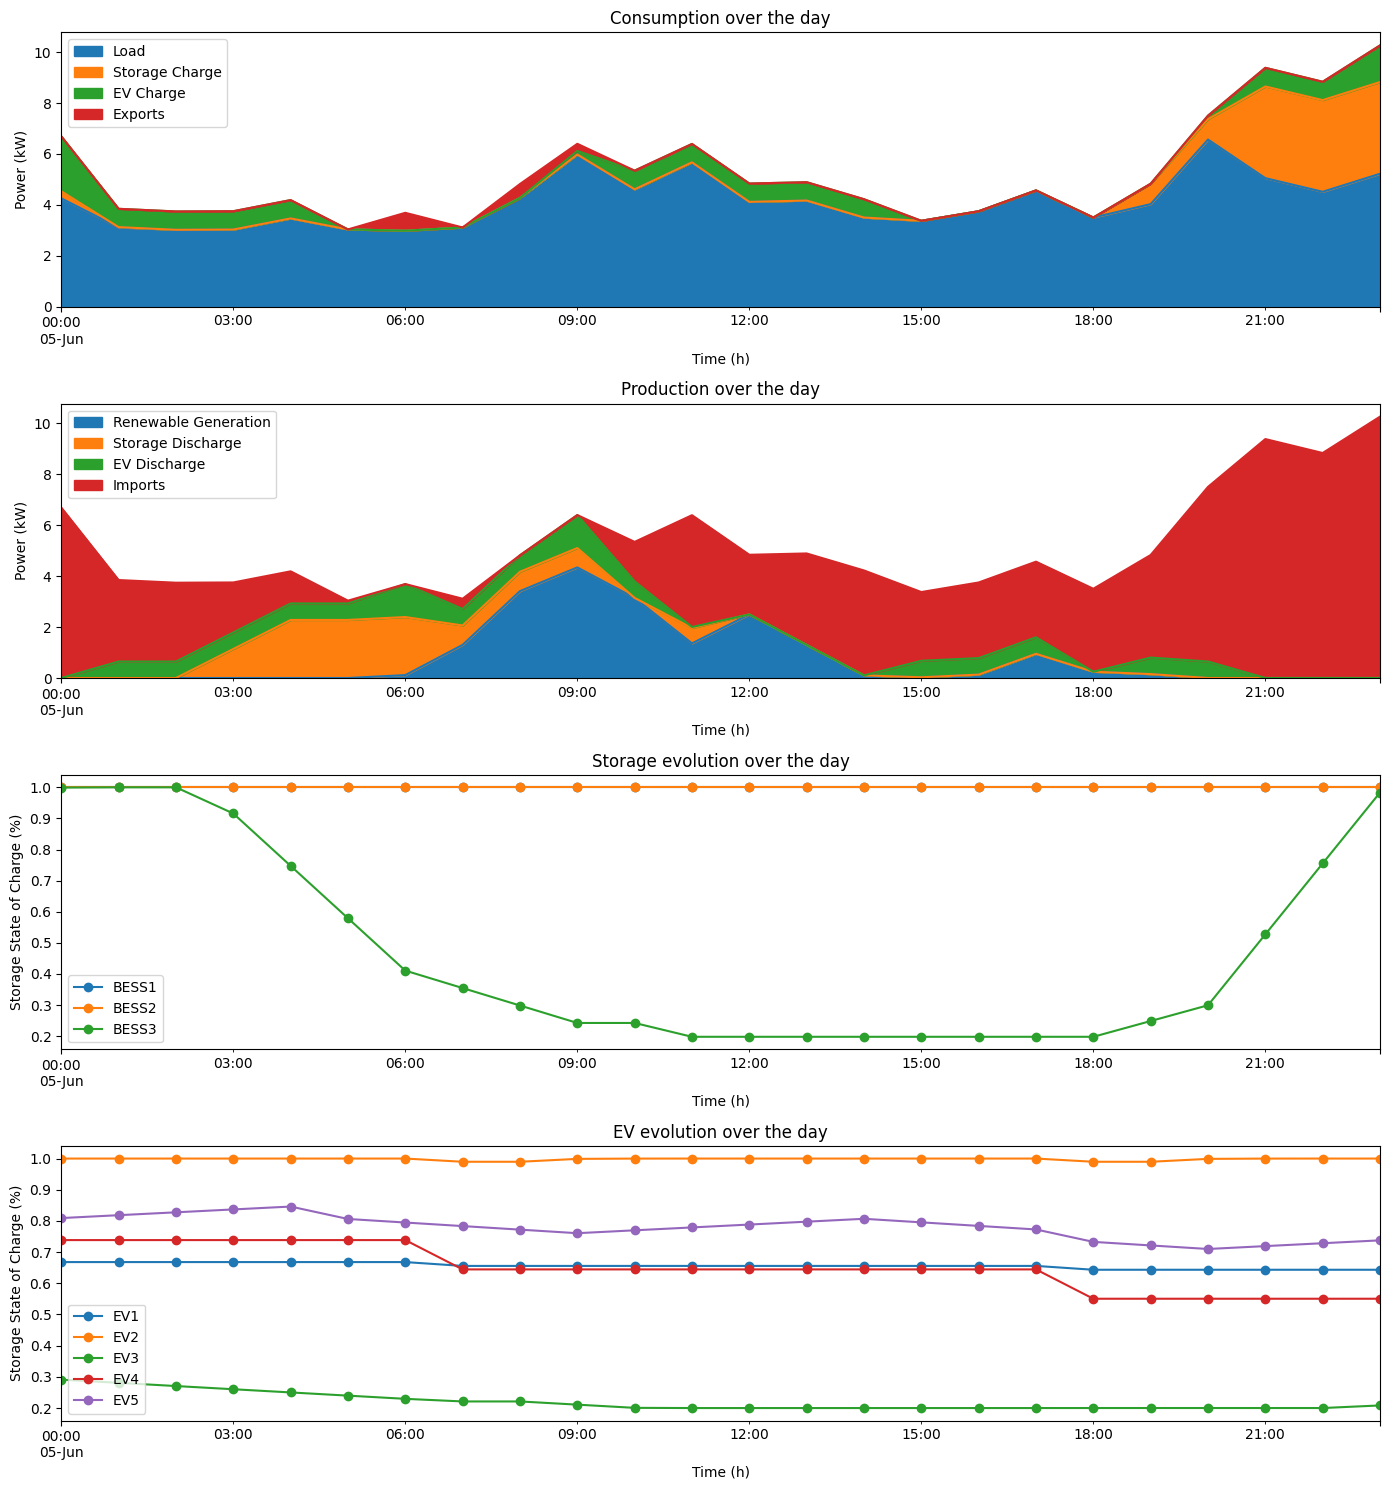

In [36]:
# Plot the resource usage over a day

DAY = '2020-6-5'
MODEL = 'adaptive'

fig, ax = plt.subplots(4, 1, figsize=(14, 15))

# Do an area plot for the consumption
consumptions[MODEL].loc[DAY].plot(kind='area', ax=ax[0], stacked=True,
                                  xlabel='Time (h)', ylabel='Power (kW)',
                                  title='Consumption over the day')

# Do an area plot for the production
productions[MODEL].loc[DAY].plot(kind='area', ax=ax[1], stacked=True,
                                 xlabel='Time (h)', ylabel='Power (kW)',
                                 title='Production over the day')

# Plot the evolution of the storages over the day
test_data[MODEL].loc[DAY][['storage_01', 'storage_02', 'storage_03']].plot(ax=ax[2], marker='o')
ax[2].set_title(f'Storage evolution over the day')
ax[2].set_ylabel('Storage State of Charge (%)')
ax[2].set_xlabel('Time (h)')
ax[2].legend(['BESS1', 'BESS2', 'BESS3'])

# Plot the evolution of the EVs over the day
test_data[MODEL].loc[DAY][['ev_01', 'ev_02', 'ev_03', 'ev_04', 'ev_05']].plot(ax=ax[3], marker='o', linestyle='-')
ax[3].set_title('EV evolution over the day')
ax[3].set_ylabel('Storage State of Charge (%)')
ax[3].set_xlabel('Time (h)')
ax[3].legend(['EV1', 'EV2', 'EV3', 'EV4', 'EV5'])

plt.tight_layout()

plt.show()

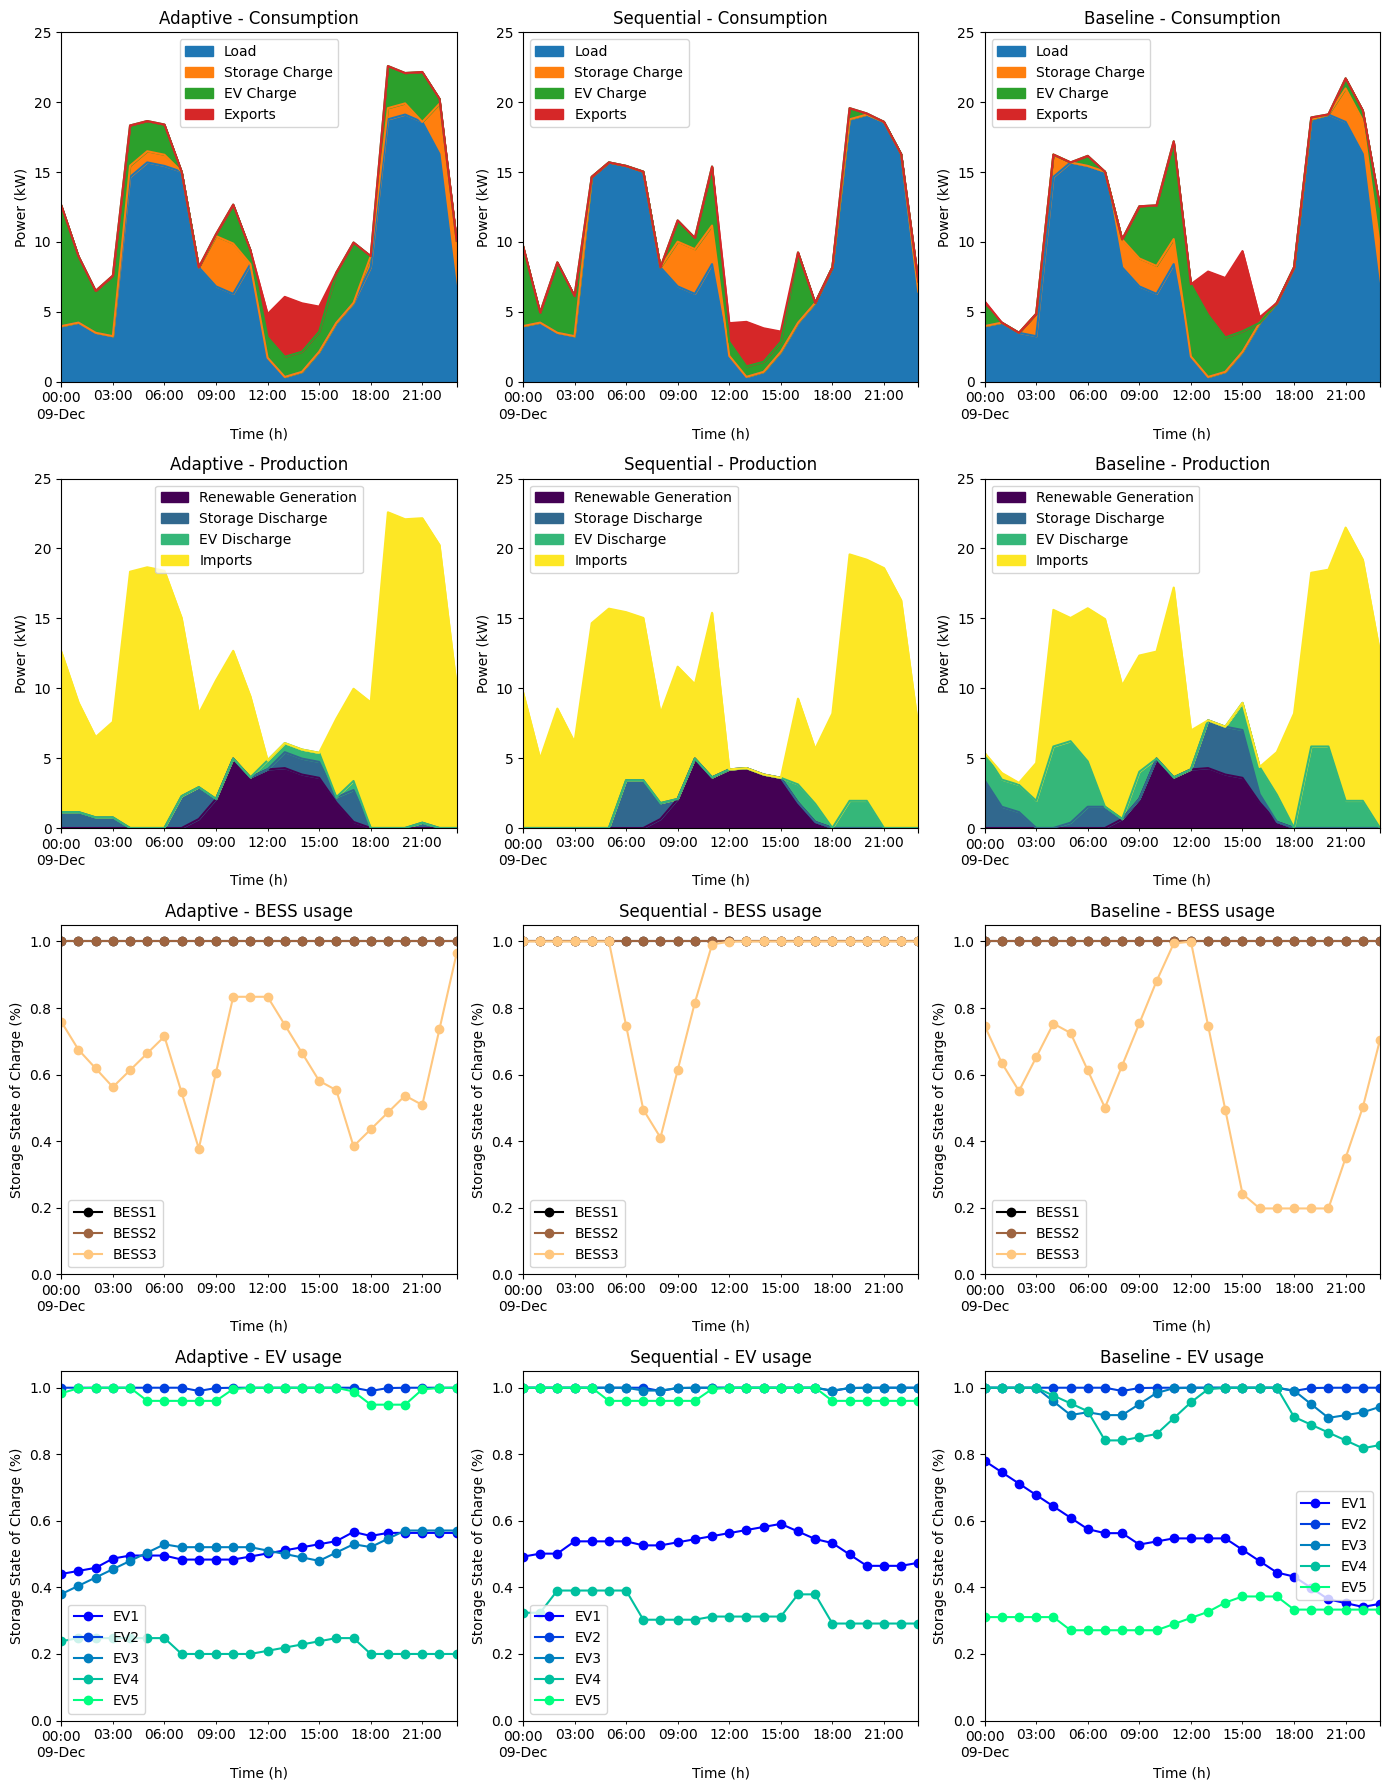

In [36]:
# Plot the resource usage over a day for all the models

DAY = '2020-12-9'

fig, ax = plt.subplots(4, 3, figsize=(14, 18))

current_model = 0
for model in test_data.keys():
    # Do an area plot for the consumption
    consumptions[model].loc[DAY].plot(kind='area', ax=ax[0, current_model], stacked=True,
                                      xlabel='Time (h)', ylabel='Power (kW)',
                                      title=f'{model.capitalize()} - Consumption',
                                      ylim=(0, 25))

    # Do an area plot for the production
    productions[model].loc[DAY].plot(kind='area', ax=ax[1, current_model], stacked=True,
                                     xlabel='Time (h)', ylabel='Power (kW)',
                                     title=f'{model.capitalize()} - Production',
                                     ylim=(0, 25), cmap='viridis')

    # Plot the evolution of the storages over the day
    test_data[model].loc[DAY][['storage_01', 'storage_02', 'storage_03']].plot(ax=ax[2, current_model], marker='o',
                                                                               cmap='copper')
    ax[2, current_model].set_ylim(0, 1.05)
    ax[2, current_model].set_title(f'{model.capitalize()} - BESS usage')
    ax[2, current_model].set_ylabel('Storage State of Charge (%)')
    ax[2, current_model].set_xlabel('Time (h)')
    ax[2, current_model].legend(['BESS1', 'BESS2', 'BESS3'])
    
    # Plot the evolution of the EVs over the day
    test_data[model].loc[DAY][['ev_01', 'ev_02', 'ev_03', 'ev_04', 'ev_05']].plot(ax=ax[3, current_model], 
                                                                                  marker='o', linestyle='-', 
                                                                                  cmap='winter')
    ax[3, current_model].set_ylim(0, 1.05)
    ax[3, current_model].set_title(f'{model.capitalize()} - EV usage')
    ax[3, current_model].set_ylabel('Storage State of Charge (%)')
    ax[3, current_model].set_xlabel('Time (h)')
    ax[3, current_model].legend(['EV1', 'EV2', 'EV3', 'EV4', 'EV5'])
    
    current_model += 1

plt.tight_layout()
plt.savefig('performance_worst_day_new.png', dpi=300)
plt.show()

In [32]:
# Calculate the SS and SC for each model

MODEL = 'sequential' #'priority_paper_v3'

df_ss_sc = pd.DataFrame({})

# Set the baseline values
df_ss_sc['baseline_prod'] = productions[MODEL]['Renewable Generation']
df_ss_sc['baseline_cons'] = consumptions[MODEL]['Load']
df_ss_sc['baseline_imports'] = df_ss_sc['baseline_cons'] - df_ss_sc['baseline_prod']
df_ss_sc['baseline_exports'] = df_ss_sc['baseline_prod'] - df_ss_sc['baseline_cons']

# Set to zero the negative values
df_ss_sc['baseline_imports'] = df_ss_sc['baseline_imports'].clip(lower=0)
df_ss_sc['baseline_exports'] = df_ss_sc['baseline_exports'].clip(lower=0)

# Set the RL values
df_ss_sc['rl_prod'] = productions[MODEL][productions[MODEL].columns[:-1]].sum(axis=1)
df_ss_sc['rl_cons'] = consumptions[MODEL][consumptions[MODEL].columns[:-1]].sum(axis=1)
df_ss_sc['rl_imports'] = productions[MODEL]['Imports']
df_ss_sc['rl_exports'] = consumptions[MODEL]['Exports']

# Set to zero the negative values
df_ss_sc['rl_imports'] = df_ss_sc['rl_imports'].clip(lower=0)
df_ss_sc['rl_exports'] = df_ss_sc['rl_exports'].clip(lower=0)

# Calculate the metrics
df_ss_sc['baseline_ss'] = (df_ss_sc['baseline_cons'] - df_ss_sc['baseline_imports']) / df_ss_sc['baseline_cons']
df_ss_sc['baseline_sc'] = (df_ss_sc['baseline_prod'] - df_ss_sc['baseline_exports']) / df_ss_sc['baseline_prod']

df_ss_sc['rl_ss'] = (df_ss_sc['rl_cons'] - df_ss_sc['rl_imports']) / df_ss_sc['rl_cons']
df_ss_sc['rl_sc'] = (df_ss_sc['rl_prod'] - df_ss_sc['rl_exports']) / df_ss_sc['rl_prod']

In [44]:
(df_ss_sc.loc['2020-6']['baseline_imports'] * dataset_resources['2020-06'][-1].import_cost).loc['2020-6-5'].sum()

6.685562818166666

In [39]:
dataset_resources['2020-01'][-1].import_cost

array([0.0643, 0.0598, 0.0598, 0.0598, 0.0598, 0.0643, 0.0643, 0.0975,
       0.0975, 0.0975, 0.1186, 0.1186, 0.0975, 0.0975, 0.0975, 0.0975,
       0.0975, 0.0975, 0.0975, 0.1186, 0.0975, 0.0643, 0.0643, 0.0643,
       0.0643, 0.0598, 0.0598, 0.0598, 0.0598, 0.0643, 0.0643, 0.0975,
       0.0975, 0.0975, 0.1186, 0.1186, 0.0975, 0.0975, 0.0975, 0.0975,
       0.0975, 0.0975, 0.0975, 0.1186, 0.0975, 0.0643, 0.0643, 0.0643,
       0.0643, 0.0598, 0.0598, 0.0598, 0.0598, 0.0643, 0.0643, 0.0975,
       0.0975, 0.0975, 0.1186, 0.1186, 0.0975, 0.0975, 0.0975, 0.0975,
       0.0975, 0.0975, 0.0975, 0.1186, 0.0975, 0.0643, 0.0643, 0.0643,
       0.0643, 0.0598, 0.0598, 0.0598, 0.0598, 0.0643, 0.0643, 0.0975,
       0.0975, 0.0975, 0.1186, 0.1186, 0.0975, 0.0975, 0.0975, 0.0975,
       0.0975, 0.0975, 0.0975, 0.1186, 0.0975, 0.0643, 0.0643, 0.0643,
       0.0643, 0.0598, 0.0598, 0.0598, 0.0598, 0.0643, 0.0643, 0.0975,
       0.0975, 0.0975, 0.1186, 0.1186, 0.0975, 0.0975, 0.0975, 0.0975,
      

In [38]:
dataset_resources.keys()

dict_keys(['2019-01', '2019-02', '2019-03', '2019-04', '2019-05', '2019-06', '2019-07', '2019-08', '2019-09', '2019-10', '2019-11', '2019-12', '2020-01', '2020-02', '2020-03', '2020-04', '2020-05', '2020-06', '2020-07', '2020-08', '2020-09', '2020-10', '2020-11', '2020-12'])

In [33]:
df_ss_sc.loc['2020-6-5'].mean().round(2)

baseline_prod       0.80
baseline_cons       4.12
baseline_imports    3.33
baseline_exports    0.00
rl_prod             0.85
rl_cons             4.86
rl_imports          4.01
rl_exports          0.00
baseline_ss         0.18
baseline_sc         1.00
rl_ss               0.16
rl_sc               1.00
dtype: float64

In [83]:
test_data['priority_paper_v3'].loc['2019-01-02']

,ren_generator_08,ren_generator_06,ren_generator_02,ren_generator_09,ren_generator_13,storage_01,storage_01_charge,storage_01_charge_eff,storage_01_discharge,storage_01_discharge_eff,...,ev_04_discharge_eff,ev_05,ev_05_charge,ev_05_charge_eff,ev_05_discharge,ev_05_discharge_eff,imports,exports,energy_history,order_history
2019-01-02 00:00:00,0.000000,0.002767,0.000000,0.000230,0.000000,0.199662,0.0,0.00,0.000000,0.000000,...,0.0,0.200000,0.00,0.000,0.00,0.000,4.555675,0.000000,-4.555675,"['ev_05', 'storage_01', 'ev_01', 'storage_03',..."
2019-01-02 01:00:00,0.000000,0.002793,0.000000,0.000240,0.000000,0.199662,0.0,0.00,0.000000,0.000000,...,0.0,0.200000,0.00,0.000,0.00,0.000,3.923973,0.000000,-3.923973,"['ev_05', 'storage_01', 'storage_03', 'ev_01',..."
2019-01-02 02:00:00,0.000000,0.002823,0.000000,0.000383,0.000000,0.199662,0.0,0.00,0.000000,0.000000,...,0.0,0.200000,0.00,0.000,0.00,0.000,3.515590,0.000000,-3.515590,"['ev_05', 'storage_03', 'storage_01', 'ev_01',..."
2019-01-02 03:00:00,0.000000,0.002943,0.000000,0.000830,0.000000,0.199662,0.0,0.00,0.000000,0.000000,...,0.0,0.200000,0.00,0.000,0.00,0.000,2.979777,0.000000,-2.979777,"['ev_05', 'storage_03', 'storage_01', 'ev_01',..."
2019-01-02 04:00:00,0.000000,0.002793,0.000000,0.000737,0.000000,0.199662,0.0,0.00,0.000000,0.000000,...,0.0,0.200000,0.00,0.000,0.00,0.000,2.884992,0.000000,-2.884992,"['ev_05', 'storage_03', 'storage_01', 'ev_01',..."
2019-01-02 05:00:00,0.000000,0.002787,0.000000,0.000763,0.000000,0.199662,0.0,0.00,0.000000,0.000000,...,0.0,0.200000,0.00,0.000,0.00,0.000,3.100495,0.000000,-3.100495,"['ev_05', 'storage_03', 'storage_01', 'ev_01',..."
2019-01-02 06:00:00,0.000000,0.002760,0.000000,0.000497,0.000000,0.199662,0.0,0.00,0.000000,0.000000,...,0.0,0.200000,0.00,0.000,0.00,0.000,4.387970,0.000000,-4.387970,"['ev_05', 'storage_03', 'storage_01', 'ev_01',..."
2019-01-02 07:00:00,0.000000,0.002913,0.000000,0.000717,0.000000,0.199662,0.0,0.00,0.000000,0.000000,...,0.0,0.200000,0.00,0.000,0.00,0.000,4.283600,0.000000,-4.283600,"['ev_05', 'storage_03', 'storage_01', 'ev_01',..."
2019-01-02 08:00:00,0.059757,0.066037,0.154230,0.473030,0.100287,0.199662,0.0,0.00,0.000000,0.000000,...,0.0,0.200000,0.00,0.000,0.00,0.000,3.740000,0.000000,-3.740000,"['ev_05', 'storage_03', 'storage_01', 'ev_01',..."
2019-01-02 09:00:00,0.712103,0.186347,0.983140,3.331280,0.979037,0.199662,0.0,0.00,0.000000,0.000000,...,0.0,0.200000,0.00,0.000,0.00,0.000,1.690607,0.000000,-1.690607,"['ev_05', 'storage_03', 'storage_01', 'ev_01',..."


In [69]:
0.199662 + (4 / 15) * 0.95  

0.4529953333333333

In [56]:
# Get the lowest cost of the df_costs_grouped for the nogen models

use_models = ['adaptive_nogen', 'seq_nogen', 'marl_nogen', 'adaptive_gen', 'seq_gen', 'marl_gen', 'adaptive_v2']

df_nogen_costs = df_costs_grouped[use_models]
df_nogen_costs['lowest_nogen'] = df_nogen_costs[use_models].idxmin(axis=1)
df_nogen_costs

/var/folders/th/r7sxqq0x56d07db0rvxmgxdc0000gn/T/ipykernel_68148/2727662600.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nogen_costs['lowest_nogen'] = df_nogen_costs[use_models].idxmin(axis=1)


adaptive_nogen   seq_nogen  marl_nogen adaptive_gen     seq_gen  \
2019 1      323.447992  335.607694   327.52823   311.672257  318.833387   
     2       279.67143  283.875529  283.284778   273.360917  281.347429   
     3      264.905106  271.169956  266.038289   255.268583  263.697937   
     4      249.487502  258.135333  252.788192   246.283173  254.426501   
     5      227.716434  233.888845  232.994311    221.83814   233.90557   
     6      251.116165  257.997264  255.029553   246.386518  251.883591   
     7      231.177644   237.11949    238.4728   227.725981  238.494317   
     8      272.583076  276.213443  274.205673   266.182967   270.42549   
     9      241.315526  253.698921   250.26416   242.953244  250.029892   
     10     283.006924  288.575544  286.000577   274.110401  281.064433   
     11     304.054742  308.753068  308.124946   298.984665  303.448587   
     12      273.80671  280.155121  275.964046   264.280569  272.257963   
2020 1      234.933591  242.108141  240.776424   224.001588  234.927806   
     2      284.434869  293.117557   291.93778   282.188538  289.713683   
     3      267.963802  265.423396  266.115689   255.804935   260.96948   
     4      191.769471  203.036139  204.925879   188.764309  209.914927   
     5      159.162918  166.764745  173.534293   155.783146  174.668452   
     6      183.325386  191.333546  196.743225   181.757182  194.936563   
     7      215.377065   223.09493  224.031544   213.015351  223.433757   
     8       228.21461  233.277865   236.69478   224.637453  235.162221   
     9      243.948295  254.366737  252.785603   244.672163  248.191273   
     10     263.854278  267.574796  265.052806   253.234596  259.867901   
     11     285.437644   294.85374  295.293446   281.129678  289.518705   
     12     309.286375  307.563908   301.20838   293.901837  299.297537   
2021 1        0.227063     0.05832    0.099016     0.046939    0.000026   

           marl_gen adaptive_v2 lowest_nogen  
2019 1   329.825597  269.446335  adaptive_v2  
     2   283.883471  239.318955  adaptive_v2  
     3   263.700341  221.534824  adaptive_v2  
     4   261.040691   210.75247  adaptive_v2  
     5   233.959833  185.794511  adaptive_v2  
     6   258.347246  213.668378  adaptive_v2  
     7   240.657481  192.353193  adaptive_v2  
     8   276.891051  228.862828  adaptive_v2  
     9    254.41999   206.53031  adaptive_v2  
     10  287.371448  239.966251  adaptive_v2  
     11  307.954136  262.512944  adaptive_v2  
     12  276.251021  233.014629  adaptive_v2  
2020 1   236.373603  192.353314  adaptive_v2  
     2   295.635617  249.821777  adaptive_v2  
     3   266.855157  221.406271  adaptive_v2  
     4   200.797586  161.266224  adaptive_v2  
     5   165.685085  126.947333  adaptive_v2  
     6   193.113661  150.618321  adaptive_v2  
     7   221.232469  176.760949  adaptive_v2  
     8   234.412286  191.110814  adaptive_v2  
     9   251.541546  207.993106  adaptive_v2  
     10  262.106812  219.839003  adaptive_v2  
     11  292.810669  249.025115  adaptive_v2  
     12  303.045346  257.154081  adaptive_v2  
2021 1     0.185203    0.046296      seq_gen

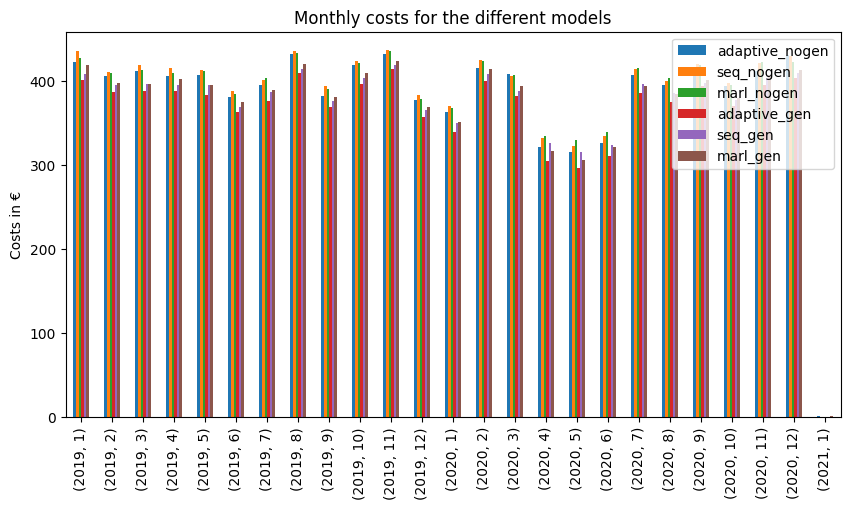

In [15]:
# Takes the df_costs_grouped and builds a bar plot

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

df_costs_grouped.plot(kind='bar', ax=ax)

ax.set_title('Monthly costs for the different models')
ax.set_ylabel('Costs in €')

plt.show()

In [306]:
# Create a dataframe highlighting the lowest cost per month

df_lowest_costs = pd.DataFrame({})
df_lowest_costs['adaptive'] = final_costs['adaptive']\
    [list(final_costs['adaptive'].columns)[:-1]].sum(axis=1)
df_lowest_costs['sequential'] = final_costs['sequential']\
    [list(final_costs['sequential'].columns)[:-1]].sum(axis=1).values
df_lowest_costs['baseline'] = final_costs['baseline']\
    [list(final_costs['baseline'].columns)[:-1]].sum(axis=1).values

df_lowest_costs['lowest'] = df_lowest_costs.idxmin(axis=1)
df_lowest_costs

,adaptive,sequential,baseline,lowest
2019-01-01 01:00:00,0.76114,1.040612,2.027544,adaptive
2019-01-01 02:00:00,1.135178,0.630229,1.579461,sequential
2019-01-01 03:00:00,1.30147,0.759752,0.597093,baseline
2019-01-01 04:00:00,1.043793,0.560015,0.338591,baseline
2019-01-01 05:00:00,0.823115,0.648181,0.499342,baseline
...,...,...,...,...
2020-12-31 20:00:00,0.325201,0.015798,0.135387,sequential
2020-12-31 21:00:00,0.026735,0.001297,0.04417,sequential
2020-12-31 22:00:00,0.001762,0.000084,0.03654,sequential
2020-12-31 23:00:00,0.000174,0.000006,0.036051,sequential


In [307]:
# Count the number of times each model is the lowest cost

df_lowest_costs.loc['2019-02':]['lowest'].value_counts()

lowest
adaptive      7937
sequential    5728
baseline      3136
Name: count, dtype: int64

In [308]:
# Group by month

df_lowest_grouped = pd.DataFrame({})
df_lowest_grouped['adaptive'] = df_lowest_costs['lowest'] == 'adaptive'
df_lowest_grouped['sequential'] = df_lowest_costs['lowest'] == 'sequential'
df_lowest_grouped['baseline'] = df_lowest_costs['lowest'] == 'baseline'

df_lowest_grouped = df_lowest_grouped['2019-02':]

df_lowest_grouped = df_lowest_grouped.groupby([df_lowest_grouped.index.hour]).sum()
df_lowest_grouped

,adaptive,sequential,baseline
0,85,571,45
1,534,119,47
2,490,145,65
3,467,135,98
4,450,99,151
5,437,112,151
6,413,148,139
7,85,73,542
8,208,88,404
9,209,164,327


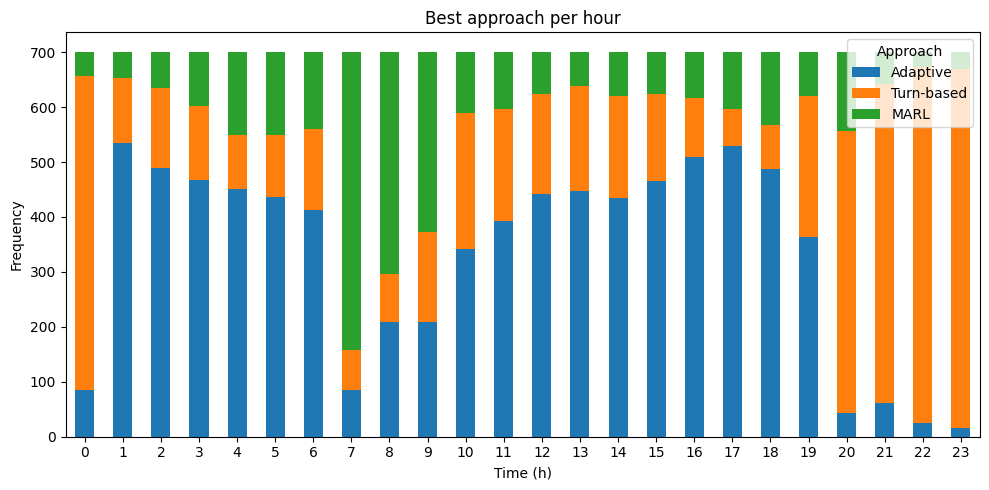

In [309]:
# Create a stacked bar plot for the lowest costs

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

df_lowest_grouped.plot(kind='bar', stacked=True, ax=ax, rot=0)

ax.set_title('Best approach per hour')
ax.set_ylabel('Frequency')
ax.set_xlabel('Time (h)')

plt.legend(['Adaptive', 'Turn-based', 'MARL'], title='Approach', loc='upper right')

plt.tight_layout()

#plt.savefig('best_approach_hourly.png', dpi=300)

plt.show()

In [18]:
df_lowest_grouped['highest'] = df_lowest_grouped.idxmax(axis=1)

In [19]:
df_lowest_grouped

,adaptive_nogen,seq_nogen,marl_nogen,highest
0,76,335,290,seq_nogen
1,96,374,230,seq_nogen
2,110,432,158,seq_nogen
3,246,340,114,seq_nogen
4,378,239,83,adaptive_nogen
5,441,207,52,adaptive_nogen
6,504,159,37,adaptive_nogen
7,350,311,39,adaptive_nogen
8,402,263,35,adaptive_nogen
9,491,152,57,adaptive_nogen


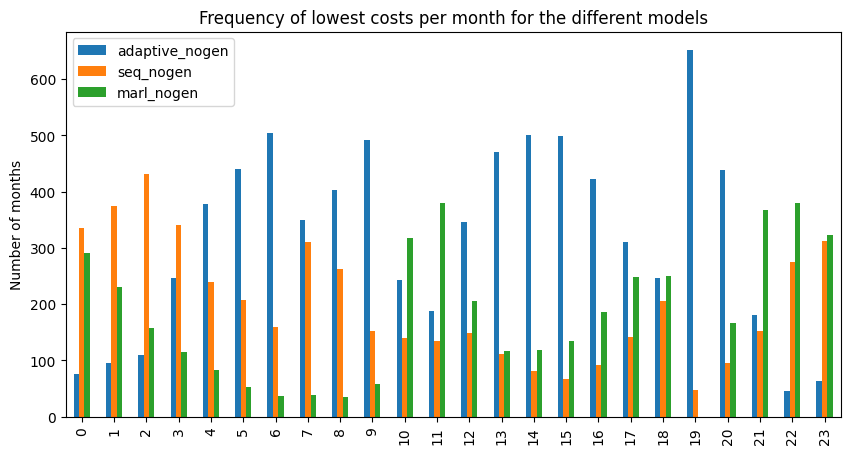

In [21]:
# Create a bar plot for the lowest costs

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

df_lowest_grouped.plot(kind='bar', ax=ax)

ax.set_title('Frequency of lowest costs per month for the different models')
ax.set_ylabel('Number of months')

plt.show()

In [17]:
# Get the sum of the costs for each hour of the day

df_costs_hourly = pd.DataFrame({})
df_costs_hourly['adaptive_nogen'] = final_costs['priority_paper_v1']\
    [list(final_costs['priority_paper_v1'].columns)[:-1]].sum(axis=1)['2019-02':'2019-12']
df_costs_hourly['seq_nogen'] = final_costs['priority_seq_paper_v1']\
    [list(final_costs['priority_seq_paper_v1'].columns)[:-1]].sum(axis=1)['2019-02':'2019-12':].values
df_costs_hourly['marl_nogen'] = final_costs['priority_baseline_paper_v1']\
    [list(final_costs['priority_baseline_paper_v1'].columns)[:-1]].sum(axis=1)['2019-02':'2019-12'].values

df_costs_hourly = df_costs_hourly.groupby([df_costs_hourly.index.hour]).sum()

# Add a new column with the lowest cost
df_costs_hourly['lowest_nogen'] = df_costs_hourly[['adaptive_nogen', 'seq_nogen', 'marl_nogen']].idxmin(axis=1)
df_costs_hourly

,adaptive_nogen,seq_nogen,marl_nogen,lowest_nogen
0,129.926438,124.202882,132.134146,seq_nogen
1,118.290661,117.262516,128.282315,seq_nogen
2,101.992856,100.559965,112.778648,seq_nogen
3,85.947553,85.452804,94.789928,seq_nogen
4,81.585768,82.586114,89.297086,adaptive_nogen
5,84.429182,84.156751,85.563361,seq_nogen
6,95.559415,96.608624,95.912641,adaptive_nogen
7,120.706793,110.225604,156.949604,seq_nogen
8,183.706471,177.112605,186.670491,seq_nogen
9,185.510317,188.625757,184.141498,marl_nogen


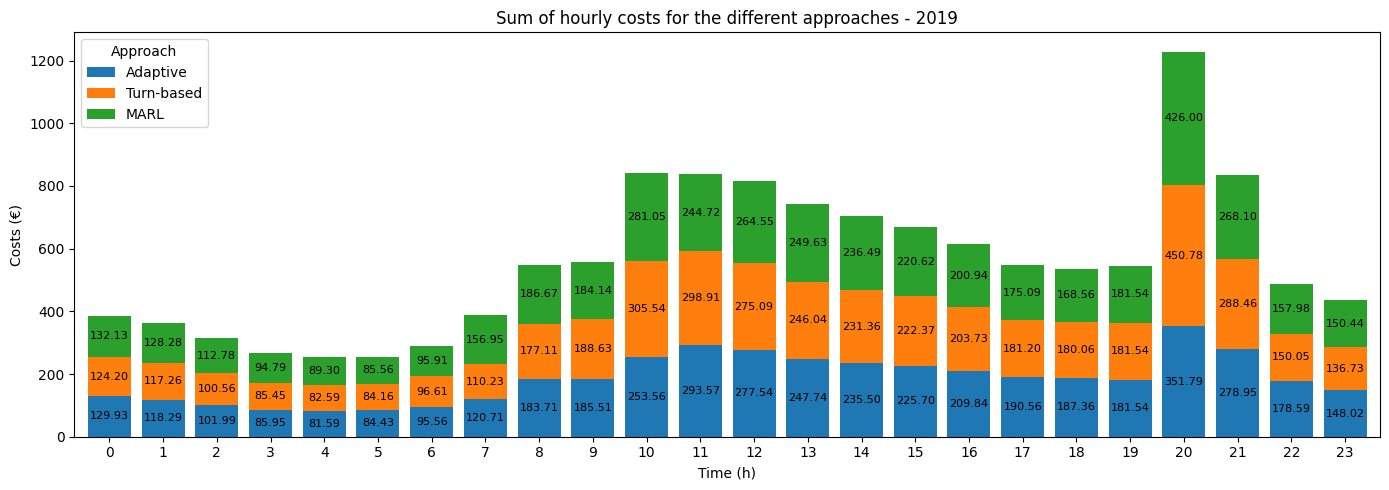

In [18]:
# Plot the hourly costs as a stacked bar

fig, ax = plt.subplots(1, 1, figsize=(14, 5))

df_costs_hourly.plot(kind='bar', stacked=True, ax=ax, rot=0, width=0.8)

for rect in ax.patches:
    # Find where everything is located
    height = rect.get_height()
    width = rect.get_width()
    x = rect.get_x()
    y = rect.get_y()

    # The height of the bar is the data value and can be used as the label
    label_text = f'{height:.2f}'  # f'{height:.2f}' to format decimal values

    # ax.text(x, y, text)
    label_x = x + width / 2
    label_y = y + height / 2

    # plot only when height is greater than specified value
    if height > 0:
        ax.text(label_x, label_y, label_text, ha='center', va='center', fontsize=8)

# Rotate the bar values
    
ax.set_ylabel('Costs (€)')
ax.set_xlabel('Time (h)')

ax.set_title('Sum of hourly costs for the different approaches - 2019')

plt.legend(['Adaptive', 'Turn-based', 'MARL'], title='Approach', loc='upper left')

plt.tight_layout()
#plt.savefig('hourly_costs_2019.png', dpi=300)

plt.show()

In [19]:
# Do the hourly costs for the 2020 data

df_costs_hourly_2020 = pd.DataFrame({})
df_costs_hourly_2020['adaptive_nogen'] = final_costs['priority_paper_v1']\
    [list(final_costs['priority_paper_v1'].columns)[:-1]].sum(axis=1)['2020']
df_costs_hourly_2020['seq_nogen'] = final_costs['priority_seq_paper_v1']\
    [list(final_costs['priority_seq_paper_v1'].columns)[:-1]].sum(axis=1)['2020'].values
df_costs_hourly_2020['marl_nogen'] = final_costs['priority_baseline_paper_v1']\
    [list(final_costs['priority_baseline_paper_v1'].columns)[:-1]].sum(axis=1)['2020'].values

df_costs_hourly_2020 = df_costs_hourly_2020.groupby([df_costs_hourly_2020.index.hour]).sum()

# Add a new column with the lowest cost
df_costs_hourly_2020['lowest_nogen'] = df_costs_hourly_2020[['adaptive_nogen', 'seq_nogen', 'marl_nogen']].idxmin(axis=1)
df_costs_hourly_2020

,adaptive_nogen,seq_nogen,marl_nogen,lowest_nogen
0,128.506254,120.468182,126.23885,seq_nogen
1,110.606067,107.882782,116.695412,seq_nogen
2,90.86288,87.90067,99.348052,seq_nogen
3,79.317886,76.39851,92.506669,seq_nogen
4,74.05411,72.329843,83.912666,seq_nogen
5,78.746303,78.579789,82.586748,seq_nogen
6,89.655155,89.991868,89.632199,marl_nogen
7,109.60854,98.309847,152.174574,seq_nogen
8,169.223921,164.766943,175.64143,seq_nogen
9,168.792094,171.760849,165.655652,marl_nogen


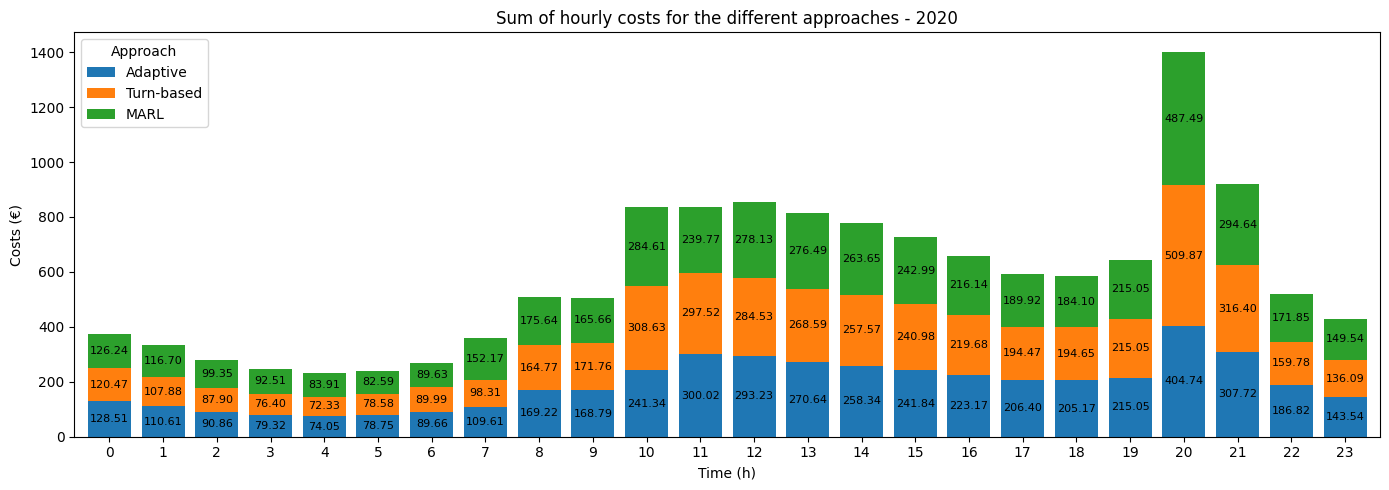

In [20]:
# Plot the hourly costs as a stacked bar

fig, ax = plt.subplots(1, 1, figsize=(14, 5))

df_costs_hourly_2020.plot(kind='bar', stacked=True, ax=ax, rot=0, width=0.8)

for rect in ax.patches:
    # Find where everything is located
    height = rect.get_height()
    width = rect.get_width()
    x = rect.get_x()
    y = rect.get_y()

    # The height of the bar is the data value and can be used as the label
    label_text = f'{height:.2f}'  # f'{height:.2f}' to format decimal values

    # ax.text(x, y, text)
    label_x = x + width / 2
    label_y = y + height / 2

    # plot only when height is greater than specified value
    if height > 0:
        ax.text(label_x, label_y, label_text, ha='center', va='center', fontsize=8)
        
# Rotate the bar values

ax.set_ylabel('Costs (€)')
ax.set_xlabel('Time (h)')

ax.set_title('Sum of hourly costs for the different approaches - 2020')

plt.legend(['Adaptive', 'Turn-based', 'MARL'], title='Approach', loc='upper left')

plt.tight_layout()

# plt.savefig('hourly_costs_2020.png', dpi=300)

plt.show()

In [18]:
# Get the order over time for the priority_paper_v1 model

df_order_history = pd.DataFrame({})
df_order_history['adaptive'] = test_data['adaptive']['order_history']
df_order_history.index = test_data['adaptive'].index

# Go through each hour and check the order
# Remove the ren_generators and aggregator from the lists
for idx in np.arange(len(df_order_history)):
    # While it's a string we'll replace the names to make it easier to read
    df_order_history.iloc[idx]['adaptive'] = df_order_history.iloc[idx]['adaptive'].replace('aggregator', 'Aggregator')
        
    df_order_history.iloc[idx]['adaptive'] = df_order_history.iloc[idx]['adaptive'].replace('ev_01', 'EV1')
    df_order_history.iloc[idx]['adaptive'] = df_order_history.iloc[idx]['adaptive'].replace('ev_02', 'EV2')
    df_order_history.iloc[idx]['adaptive'] = df_order_history.iloc[idx]['adaptive'].replace('ev_03', 'EV3')
    df_order_history.iloc[idx]['adaptive'] = df_order_history.iloc[idx]['adaptive'].replace('ev_04', 'EV4')
    df_order_history.iloc[idx]['adaptive'] = df_order_history.iloc[idx]['adaptive'].replace('ev_05', 'EV5')
    df_order_history.iloc[idx]['adaptive'] = df_order_history.iloc[idx]['adaptive'].replace('storage_01', 'BESS1')
    df_order_history.iloc[idx]['adaptive'] = df_order_history.iloc[idx]['adaptive'].replace('storage_02', 'BESS2')
    df_order_history.iloc[idx]['adaptive'] = df_order_history.iloc[idx]['adaptive'].replace('storage_03', 'BESS3')

    df_order_history.iloc[idx]['adaptive'] = df_order_history.iloc[idx]['adaptive'].split(',')[:-1]
    
# Create a new column with the order as string
df_order_history['order_str'] = df_order_history['adaptive'].apply(lambda x: ','.join(x))
df_order_history['order_str'] = df_order_history['order_str'].str.replace('[', '')
df_order_history['order_str'] = df_order_history['order_str'].str.replace(']', '')
df_order_history['order_str'] = df_order_history['order_str'].str.replace('\'', '')
    
# Add a column with the order encoded
unique_orders = sorted(set(df_order_history['order_str']))
encoded_orders = {ch: i for i, ch in enumerate(unique_orders)}
df_order_history['order'] = [encoded_orders[i] for i in df_order_history['order_str']]

In [19]:
df_order_history

,adaptive,order_str,order
2019-01-01 00:00:00,"[['EV2', 'EV4', 'EV1', 'EV5', 'EV3', 'BES...","EV2, EV4, EV1, EV5, EV3, BESS3, BESS1, BESS2",9
2019-01-01 01:00:00,"[['EV5', 'BESS1', 'BESS3', 'EV4', 'EV2', ...","EV5, BESS1, BESS3, EV4, EV2, EV1, BESS2, EV3",67
2019-01-01 02:00:00,"[['EV5', 'BESS1', 'EV4', 'BESS2', 'EV2', ...","EV5, BESS1, EV4, BESS2, EV2, BESS3, EV1, EV3",68
2019-01-01 03:00:00,"[['EV5', 'BESS2', 'EV4', 'BESS1', 'BESS3',...","EV5, BESS2, EV4, BESS1, BESS3, EV2, EV1, EV3",69
2019-01-01 04:00:00,"[['EV5', 'BESS2', 'EV4', 'BESS1', 'BESS3',...","EV5, BESS2, EV4, BESS1, BESS3, EV2, EV1, EV3",69
...,...,...,...
2020-12-31 19:00:00,"[['EV5', 'BESS3', 'EV3', 'EV1', 'EV4', 'E...","EV5, BESS3, EV3, EV1, EV4, EV2, BESS1, BESS2",75
2020-12-31 20:00:00,"[['EV5', 'BESS3', 'EV3', 'EV1', 'EV4', 'E...","EV5, BESS3, EV3, EV1, EV4, EV2, BESS1, BESS2",75
2020-12-31 21:00:00,"[['EV5', 'BESS3', 'EV3', 'EV1', 'EV4', 'E...","EV5, BESS3, EV3, EV1, EV4, EV2, BESS1, BESS2",75
2020-12-31 22:00:00,"[['EV5', 'BESS3', 'EV3', 'EV1', 'EV4', 'E...","EV5, BESS3, EV3, EV1, EV4, EV2, BESS1, BESS2",75


In [20]:
len(unique_orders)

117

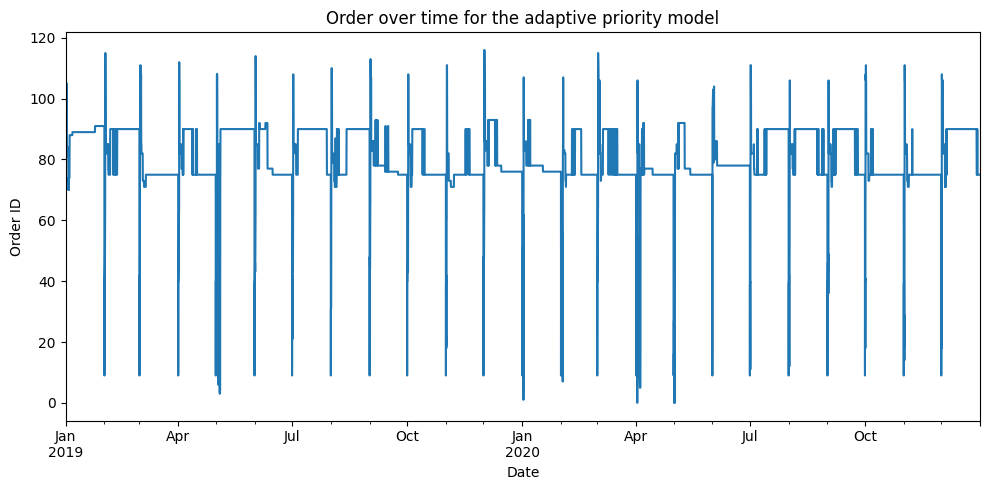

In [21]:
# Plot the order over time

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

df_order_history['order'].plot(ax=ax)

ax.set_title('Order over time for the adaptive priority model')
ax.set_ylabel('Order ID')
ax.set_xlabel('Date')

plt.tight_layout()

plt.savefig('order_over_time.png', dpi=300)

plt.show()

In [22]:
df_order_history['order'].value_counts()

order
75    6578
90    5171
78    1222
76     988
82     506
      ... 
60       1
53       1
38       1
1        1
58       1
Name: count, Length: 117, dtype: int64

In [24]:
# Calculate the frequency of the orders

df_order_freq = pd.DataFrame({})
df_order_freq['adaptive'] = df_order_history['order'].value_counts()
df_order_freq['adaptive'] = df_order_freq['adaptive'] / df_order_freq['adaptive'].sum()
df_order_freq.round(2)

,adaptive
order,
75,0.37
90,0.29
78,0.07
76,0.06
82,0.03
...,...
60,0.00
53,0.00
38,0.00


In [321]:
df_order_history.loc[df_order_history['order'] == 78]['order_str'].head(1)

2019-09-04 05:00:00    EV5, BESS3, EV3, EV4, EV1, EV2, BESS2, BESS1
Name: order_str, dtype: object

In [323]:
df_order_history

,adaptive,order_str,order
2019-01-01 00:00:00,"[['EV2', 'EV4', 'EV1', 'EV5', 'EV3', 'BES...","EV2, EV4, EV1, EV5, EV3, BESS3, BESS1, BESS2",9
2019-01-01 01:00:00,"[['EV5', 'BESS1', 'BESS3', 'EV4', 'EV2', ...","EV5, BESS1, BESS3, EV4, EV2, EV1, BESS2, EV3",67
2019-01-01 02:00:00,"[['EV5', 'BESS1', 'EV4', 'BESS2', 'EV2', ...","EV5, BESS1, EV4, BESS2, EV2, BESS3, EV1, EV3",68
2019-01-01 03:00:00,"[['EV5', 'BESS2', 'EV4', 'BESS1', 'BESS3',...","EV5, BESS2, EV4, BESS1, BESS3, EV2, EV1, EV3",69
2019-01-01 04:00:00,"[['EV5', 'BESS2', 'EV4', 'BESS1', 'BESS3',...","EV5, BESS2, EV4, BESS1, BESS3, EV2, EV1, EV3",69
...,...,...,...
2020-12-31 19:00:00,"[['EV5', 'BESS3', 'EV3', 'EV1', 'EV4', 'E...","EV5, BESS3, EV3, EV1, EV4, EV2, BESS1, BESS2",75
2020-12-31 20:00:00,"[['EV5', 'BESS3', 'EV3', 'EV1', 'EV4', 'E...","EV5, BESS3, EV3, EV1, EV4, EV2, BESS1, BESS2",75
2020-12-31 21:00:00,"[['EV5', 'BESS3', 'EV3', 'EV1', 'EV4', 'E...","EV5, BESS3, EV3, EV1, EV4, EV2, BESS1, BESS2",75
2020-12-31 22:00:00,"[['EV5', 'BESS3', 'EV3', 'EV1', 'EV4', 'E...","EV5, BESS3, EV3, EV1, EV4, EV2, BESS1, BESS2",75


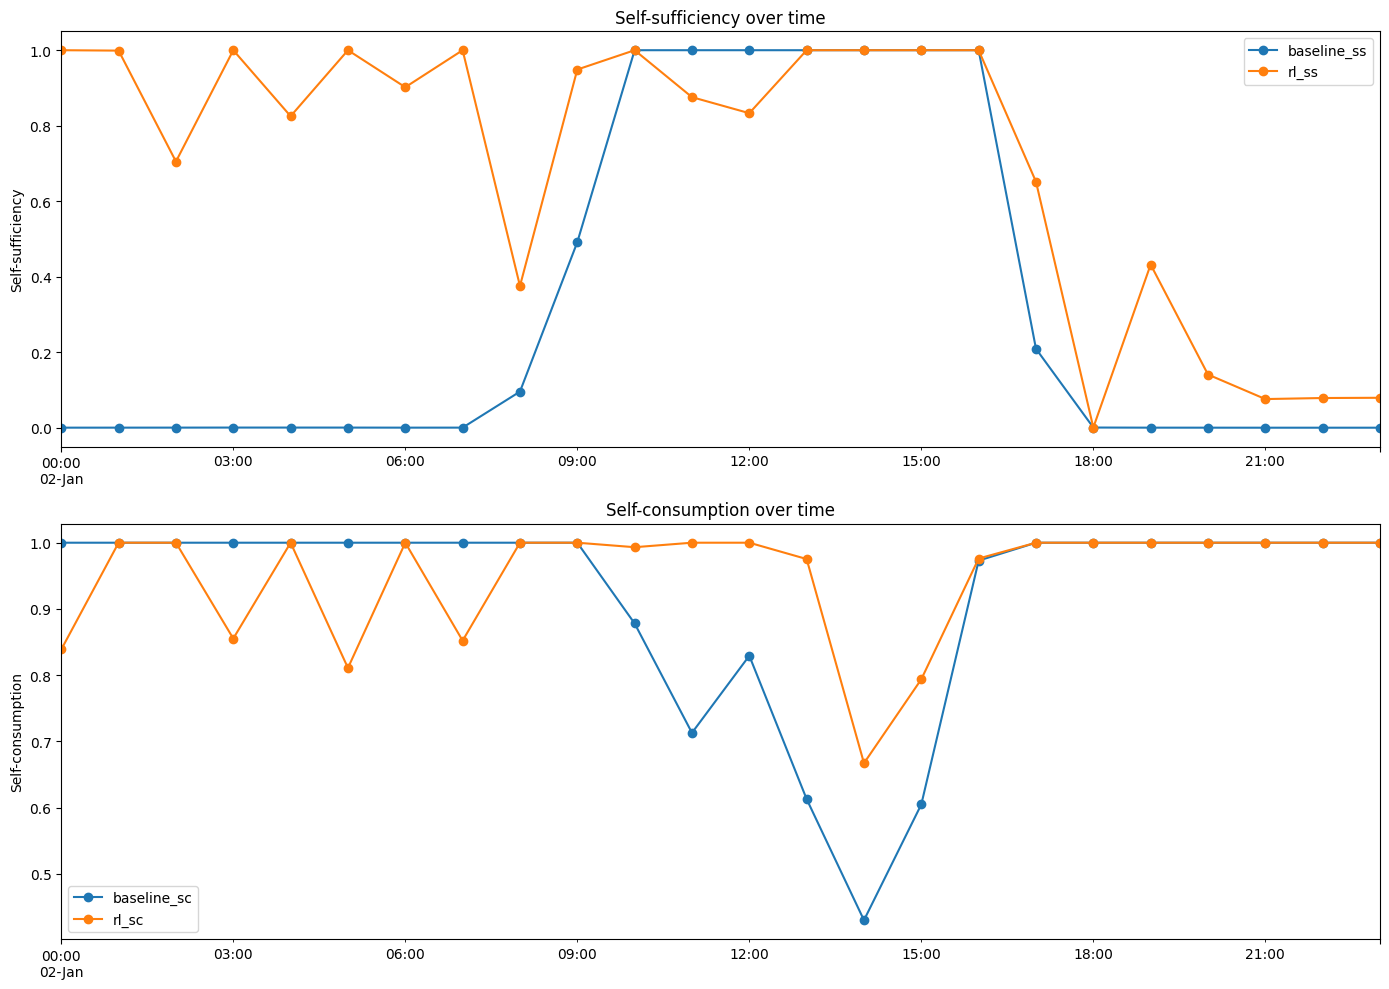

In [56]:
# Plot the SS and SC for the different models

fig, ax = plt.subplots(2, 1, figsize=(14, 10))

DAY = '2019-01-02'

df_ss_sc[['baseline_ss', 'rl_ss']].loc[DAY].plot(ax=ax[0], marker='o')

ax[0].set_title('Self-sufficiency over time')
ax[0].set_ylabel('Self-sufficiency')

df_ss_sc[['baseline_sc', 'rl_sc']].loc[DAY].plot(ax=ax[1], marker='o')

ax[1].set_title('Self-consumption over time')
ax[1].set_ylabel('Self-consumption')

plt.tight_layout()

plt.show()

In [37]:
consumptions[MODEL].keys()

Index(['load', 'storage_charge', 'ev_charge', 'exports'], dtype='object')

<Axes: >

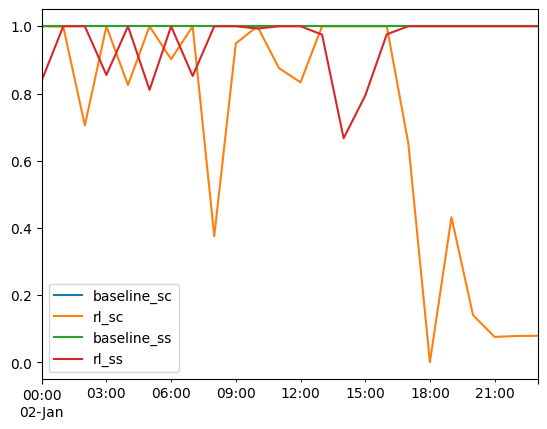

In [39]:
df_ss_sc.loc['2019-01-02'].plot()

In [31]:
test_data['priority_baseline_paper_v2'][['ren_generator_02', 'ren_generator_06',
                                         'ren_generator_08', 'ren_generator_09',
                                         'ren_generator_13']].sum(axis=1).loc['2019-01-02']

2019-01-02 00:00:00    0.0
2019-01-02 01:00:00    0.0
2019-01-02 02:00:00    0.0
2019-01-02 03:00:00    0.0
2019-01-02 04:00:00    0.0
2019-01-02 05:00:00    0.0
2019-01-02 06:00:00    0.0
2019-01-02 07:00:00    0.0
2019-01-02 08:00:00    0.0
2019-01-02 09:00:00    0.0
2019-01-02 10:00:00    0.0
2019-01-02 11:00:00    0.0
2019-01-02 12:00:00    0.0
2019-01-02 13:00:00    0.0
2019-01-02 14:00:00    0.0
2019-01-02 15:00:00    0.0
2019-01-02 16:00:00    0.0
2019-01-02 17:00:00    0.0
2019-01-02 18:00:00    0.0
2019-01-02 19:00:00    0.0
2019-01-02 20:00:00    0.0
2019-01-02 21:00:00    0.0
2019-01-02 22:00:00    0.0
2019-01-02 23:00:00    0.0
dtype: float64

In [22]:
sum(test_data['priority_baseline_paper_v2']['ev_01_discharge']>1)

0

In [337]:
for i in range(2, 7):
    print(f"EV name: {dataset_resources['2019-01'][-i].name}")
    print(f"EV capacity max: {dataset_resources['2019-01'][-i].capacity_max}")
    print(f"EV requirements sum: {dataset_resources['2019-01'][-i].schedule_requirement_soc.sum()}")
    print('\n')

EV name: ev_05
EV capacity max: 70.2
EV requirements sum: 166.60799999999978


EV name: ev_04
EV capacity max: 68.0
EV requirements sum: 391.33119999999985


EV name: ev_03
EV capacity max: 78.0
EV requirements sum: 41.87039999999976


EV name: ev_02
EV capacity max: 13.5
EV requirements sum: 8.278199999999957


EV name: ev_01
EV capacity max: 70.2
EV requirements sum: 52.09439999999978


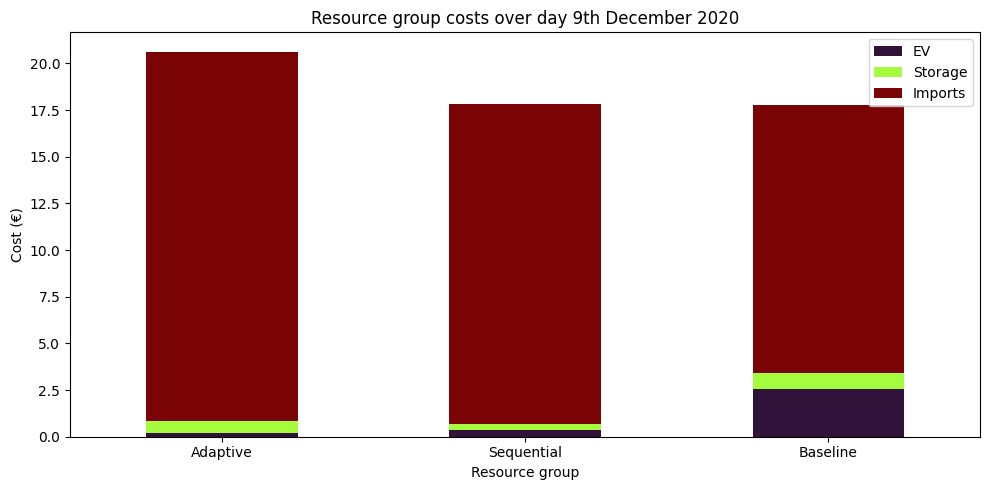

In [38]:
# Plot the costs of actions for a day

DAY = '2020-12-9'

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

df_plot_costs = pd.DataFrame({})

for key in final_costs.keys():
    df_plot_costs.loc[key.capitalize(), 'EV'] = final_costs[key].loc[DAY][['ev_01_discharge', 'ev_02_discharge',
                                                          'ev_03_discharge', 'ev_04_discharge',
                                                          'ev_05_discharge']].sum(axis=1).sum()
    df_plot_costs.loc[key.capitalize(), 'Storage'] = final_costs[key].loc[DAY][['storage_01_discharge', 'storage_02_discharge',
                                                               'storage_03_discharge']].sum(axis=1).sum()
    df_plot_costs.loc[key.capitalize(), 'Imports'] = final_costs[key].loc[DAY]['imports'].sum()
    
# Do a stacked bar plot for the costs with each bar being a different model
df_plot_costs.plot(kind='bar', stacked=True, ax=ax, rot=0, cmap='turbo')

ax.set_title('Resource group costs over day 9th December 2020')
ax.set_ylabel('Cost (€)')
ax.set_xlabel('Resource group')

plt.tight_layout()

plt.savefig('resource_costs_worst_day_new.png', dpi=300)

plt.show()

In [25]:
df_plot_costs.sum(axis=1)

Adaptive       7.911742
Sequential     7.884089
Baseline      11.054245
dtype: float64